<a href="https://colab.research.google.com/github/tanmayzalke26/Machine_Learning_Practicals/blob/main/Practical_7.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

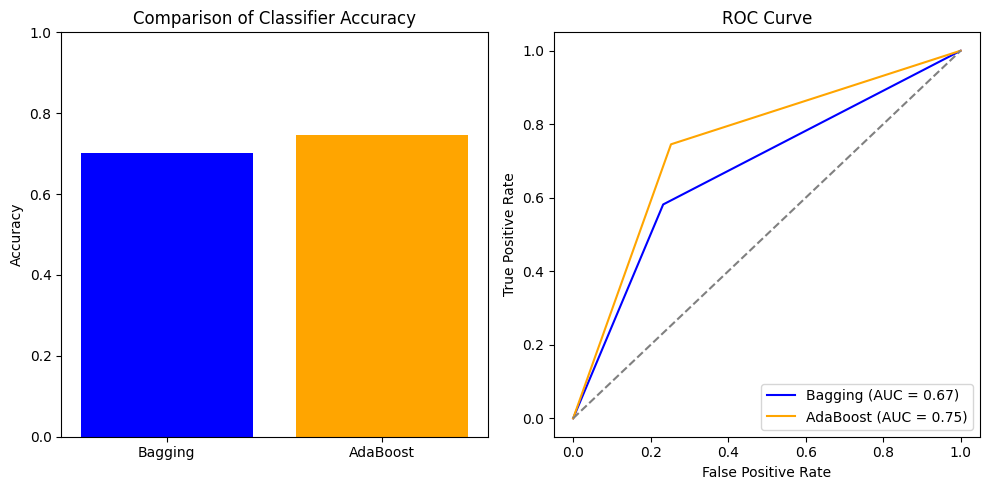

In [6]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import BaggingClassifier, AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, roc_curve, auc
import matplotlib.pyplot as plt

data = pd.read_csv('/content/diabete.csv')
X = data.drop('Outcome', axis=1)
y = data['Outcome']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

bagging_classifier = BaggingClassifier(estimator=DecisionTreeClassifier(), n_estimators=10, random_state=42)
bagging_classifier.fit(X_train, y_train)
y_pred_bagging = bagging_classifier.predict(X_test)
accuracy_bagging = accuracy_score(y_test, y_pred_bagging)

adaboost_classifier = AdaBoostClassifier(DecisionTreeClassifier(), n_estimators=10, random_state=42)
adaboost_classifier.fit(X_train, y_train)
y_pred_adaboost = adaboost_classifier.predict(X_test)
accuracy_adaboost = accuracy_score(y_test, y_pred_adaboost)

# ROC Curve calculations
fpr_bagging, tpr_bagging, _ = roc_curve(y_test, y_pred_bagging)
roc_auc_bagging = auc(fpr_bagging, tpr_bagging)

fpr_adaboost, tpr_adaboost, _ = roc_curve(y_test, y_pred_adaboost)
roc_auc_adaboost = auc(fpr_adaboost, tpr_adaboost)

# Visualization
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
models = ['Bagging', 'AdaBoost']
accuracies = [accuracy_bagging, accuracy_adaboost]
plt.bar(models, accuracies, color=['blue', 'orange'])
plt.ylabel('Accuracy')
plt.title('Comparison of Classifier Accuracy')
plt.ylim([0, 1])

plt.subplot(1, 2, 2)
plt.plot(fpr_bagging, tpr_bagging, color='blue', label=f'Bagging (AUC = {roc_auc_bagging:.2f})')
plt.plot(fpr_adaboost, tpr_adaboost, color='orange', label=f'AdaBoost (AUC = {roc_auc_adaboost:.2f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc='lower right')

plt.tight_layout()
plt.show()